In [3]:
# Install the ODS engine and import pandas for data manipulation
!pip install odfpy
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=74b3321412f05132a07ef0988f23013c8d0c31fed77bd444662653f9a9eb081c
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


In [6]:
# Load the raw ODS spreadsheet into a dataframe using the odf engine
df = pd.read_excel('StreetSwift.ods', engine='odf')

The StreetSwift dataset is now ready to be manipulated.

---
The next step is a quick clean up.


In [7]:
# Remove identical rows to ensure each Trip_ID is only counted once
df = df.drop_duplicates(subset='Trip_ID')

Quick verification. (Entries).

In [8]:
display(df['Trip_ID'].nunique())

60

In [9]:
# Convert all date strings into a uniform datetime object for trend analysis
df['Date'] = pd.to_datetime(df['Date'])

Checking for missing values.

In [10]:
# Fill empty billing cells by multiplying usage hours by the $15 hourly rate
df['Total_Bill'] = df['Total_Bill'].fillna(df['Hours_Used'] * 15)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Trip_ID      60 non-null     int64         
 1   User_ID      60 non-null     object        
 2   Car_Type     60 non-null     object        
 3   Date         60 non-null     datetime64[ns]
 4   Hours_Used   60 non-null     float64       
 5   Total_Bill   60 non-null     float64       
 6   City_Zone    60 non-null     object        
 7   User_Rating  60 non-null     int64         
 8   Status       60 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 4.3+ KB


Sanity Check:


---



The dataset now contains 60 entries (rows) and 9 columns. All columns have 60 non-null values, indicating that there are no missing values after handling `Total_Bill`. The `Date` column is correctly formatted as datetime objects, and other columns have appropriate data types (`int64`, `float64`, `object`).

Calculating ratings and total revenue by CityZone.

In [13]:
# Calculate the total revenue per City_Zone
df.groupby('City_Zone')['Total_Bill'].sum()

,Total_Bill
City_Zone,
Airport,1641.0
Downtown,832.5
Industrial,220.5
Suburbs,804.0


In [12]:
# Group data by City_Zone to calculate average ratings and total revenue
df.groupby('City_Zone')[['Total_Bill', 'User_Rating']].mean()

,Total_Bill,User_Rating
City_Zone,,
Airport,109.400000,3.266667
Downtown,46.250000,4.666667
Industrial,20.045455,1.454545
Suburbs,50.250000,3.750000


Plotting our insights.

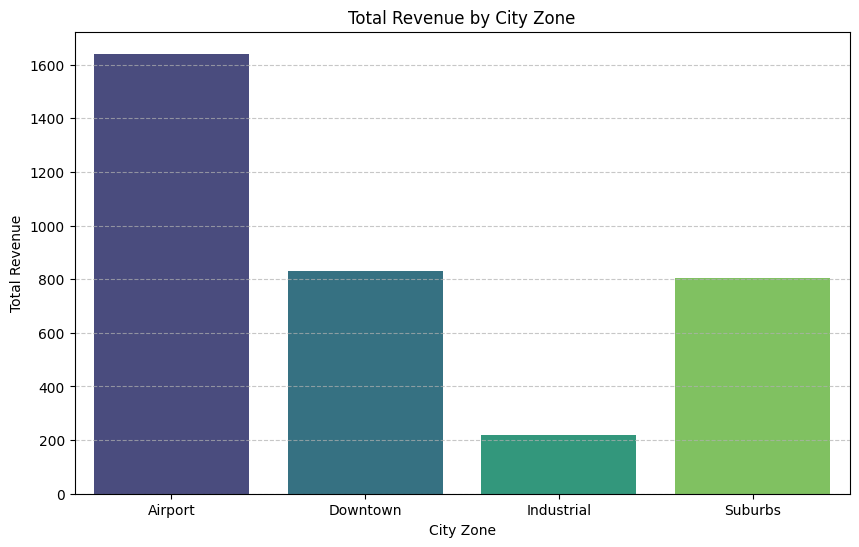

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue per City_Zone
total_revenue_by_zone = df.groupby('City_Zone')['Total_Bill'].sum().reset_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='City_Zone', y='Total_Bill', hue='City_Zone', data=total_revenue_by_zone, palette='viridis', legend=False)
plt.title('Total Revenue by City Zone')
plt.xlabel('City Zone')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusion

The analysis reveals that the **Airport** zone generates the highest total revenue and has the highest average hours used. Conversely, the **Industrial** zone has the lowest revenue and average hours used, indicating it's the least profitable area for the business. This suggests a need to investigate the challenges or lack of demand in the Industrial zone and potentially focus on strategies to enhance performance there, or reallocate resources to higher-performing zones like the Airport.

Excell ready files.

In [23]:
# Export the cleaned DataFrame to an Excel file
df.to_excel('StreetSwift_cleaned.xlsx', index=False)
print('DataFrame df successfully exported to StreetSwift_cleaned.xlsx')

DataFrame df successfully exported to StreetSwift_cleaned.xlsx


In [24]:
total_revenue_by_zone.to_excel('total_revenue_by_zone.xlsx', index=False)
print('DataFrame total_revenue_by_zone successfully exported to total_revenue_by_zone.xlsx')

DataFrame total_revenue_by_zone successfully exported to total_revenue_by_zone.xlsx
